**process cmip5 data and  compute indicators**

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import os
from utils_indicators import *
import utils_GPR as ut
from plot_optimization import *
import utils_knn as ut_knn

In [2]:
new_directory = "/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization"
os.chdir(new_directory)
print(os.getcwd())

/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization


In [3]:
#read in cmip5 data
result_loc = 'data/Annual_GPR'
#read in YrDf_cmip5_2300.csv (log, standarized data)
YrDf = pd.read_csv(f'{result_loc}/YrDf_cmip5_2300.csv')
YrDf

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,1875,-0.030201,1.063186,0.819089,-0.258966,-1.294383,-1.322708,-1.682490,0.787112,-0.694233,-0.601572,-1.425760,-1.001183,-1.460050,-1.082570,1.244272,0.076104
1,1876,0.748215,-0.567122,0.200702,-0.684366,-2.473091,-0.728954,1.000202,1.270939,-0.173343,0.045697,0.624418,0.048011,-0.478581,-0.196211,-0.154877,0.310843
2,1877,0.616387,-0.642974,-2.163925,2.119356,0.083858,1.205171,0.122969,-1.145630,0.825325,-1.626903,1.460715,-0.345251,-0.362544,-0.153591,-0.262410,1.795133
3,1878,0.244487,1.179965,0.492212,1.032967,0.082436,-0.562930,-0.958975,-0.203594,0.673849,0.588461,-0.024017,-0.058898,2.128490,-2.932302,-2.470600,-0.624879
4,1879,-0.251457,-1.363517,0.098278,1.405515,-0.093115,-0.440323,-1.174225,1.651659,1.202409,0.146836,-1.418209,-0.205862,-0.955115,0.374352,0.209996,0.722895
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,2270,0.067186,2.650183,1.100312,1.180426,-0.297521,-0.955549,-1.965426,2.219558,1.605355,-1.918038,-1.185355,0.220237,2.640492,2.244994,-1.326930,0.528663
396,2271,0.094028,2.338841,1.196006,-0.595557,0.552326,-0.741119,-0.166073,2.106040,1.658301,-0.442020,-1.539291,0.434525,-0.006189,1.875816,0.096594,-1.217773
397,2272,0.254336,2.809251,0.299393,0.445996,0.338341,-0.260635,2.213026,0.436409,0.133691,-0.356900,-0.831857,-0.960644,1.857656,2.650134,0.788353,-1.617693
398,2273,-0.349718,-0.030402,1.430127,0.764233,0.794747,0.717766,0.385129,-0.323224,1.269594,0.717672,-0.790535,0.257693,1.304048,2.450325,-0.596567,-0.207683


In [56]:
smoothed_50yrDf_cmip5 = pd.read_csv(f'{result_loc}/smoothed_50yrDf_cmip5_2300.csv')
smoothed_50yrDf_cmip5

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,1875,0.028495,-0.122567,0.000147,-0.019499,-0.050919,-0.020543,0.116743,0.132694,0.050249,-0.083561,-0.054462,-0.108753,0.018660,-0.009778,0.177955,-0.010928
1,1876,0.023209,-0.113460,0.010487,-0.034814,-0.057276,-0.018740,0.110115,0.147592,0.023938,-0.103911,-0.029115,-0.093533,0.006472,-0.056006,0.187425,-0.008386
2,1877,-0.004647,-0.076525,0.006026,0.008936,0.009830,-0.016914,0.066107,0.177782,0.034356,-0.110736,-0.020851,-0.055584,-0.004329,-0.065826,0.193219,-0.003538
3,1878,-0.017295,-0.042616,0.007786,0.036903,-0.034187,-0.013110,0.020861,0.171321,0.088692,-0.080589,-0.003678,-0.075136,-0.039910,-0.019374,0.126161,-0.034980
4,1879,0.016346,-0.090525,-0.033355,0.045469,-0.080049,-0.007857,0.033859,0.110381,0.104766,-0.079628,-0.014945,-0.066395,-0.051486,-0.000961,0.050443,-0.082128
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,2270,0.144233,1.981402,1.161844,0.099546,0.934978,-0.171347,0.238054,0.742684,-0.137772,-0.762193,-0.957345,0.646356,0.463928,2.182644,0.634054,-0.395833
396,2271,0.138103,1.999213,1.156259,0.113880,0.926645,-0.118285,0.174087,0.743820,-0.133067,-0.771906,-0.951179,0.666036,0.449773,2.207173,0.649598,-0.445677
397,2272,0.125080,2.006846,1.143153,0.084011,0.941788,-0.115119,0.143493,0.766202,-0.129040,-0.767686,-0.971129,0.687609,0.487774,2.248855,0.647311,-0.476763
398,2273,0.128548,2.001573,1.086610,0.051343,0.924015,-0.095421,0.165438,0.788233,-0.149742,-0.798493,-0.962943,0.700069,0.475081,2.280892,0.612801,-0.449198


In [18]:
#filter year from 2000 to 2100
YrDf_df = YrDf[(YrDf['years']>=2000) & (YrDf['years']<2100)]
YrDf_df.reset_index(drop=True, inplace=True)
YrDf_df

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,2000,1.870676,-0.053628,-0.278188,0.018865,0.110855,-0.732162,-0.783500,-1.239302,-1.229495,0.185012,-0.047389,-0.269534,1.271039,0.800698,-1.355688,1.241231
1,2001,0.825793,1.928204,-1.382709,0.223146,1.692481,-0.389609,1.060305,0.058810,-0.212623,-1.650667,-1.320508,0.233694,2.232877,0.874636,0.113651,0.217350
2,2002,1.294828,-0.195813,0.766609,-0.234192,0.974638,-0.732149,-0.587385,1.235835,-1.917303,-0.264409,-1.089689,1.730146,-0.920634,-0.088703,0.958405,-1.099155
3,2003,1.432168,-1.824700,1.418337,1.315986,1.032752,-0.176417,0.607772,-3.499694,-2.020465,1.526778,-0.687126,-0.766148,-0.386824,1.009353,-1.089467,0.234326
4,2004,1.567256,1.969830,0.194242,-2.369188,1.259176,-1.050452,-0.330021,-2.498731,-0.425701,-0.355474,0.291005,0.224065,-0.926335,-1.151522,0.407449,0.652614
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,2095,0.828949,1.064684,0.422862,-0.030774,1.214109,-0.280241,-0.480162,0.519158,2.265845,-2.480156,0.011971,2.201294,0.915768,1.948267,-1.110714,0.941818
96,2096,0.742418,4.048290,-1.227723,1.587236,1.141017,1.226065,1.928898,-1.035765,0.771316,0.135525,-0.688433,1.201334,-0.976906,1.125904,1.329600,-0.269186
97,2097,0.312382,1.478508,1.013708,0.313569,-0.722964,0.108087,0.400262,0.283300,-0.827383,-1.113234,-1.221766,1.045921,1.233327,1.742581,1.671664,-1.927623
98,2098,1.869785,1.588106,2.290706,-0.417814,1.963699,-0.626765,0.305759,1.206823,0.018721,-0.749847,-0.519836,0.805591,2.384267,2.237058,0.681634,0.101014


In [68]:
#filter year from 2000 to 2100
YrDf_df = YrDf[(YrDf['years']>=2000) & (YrDf['years']<2100)]
YrDf_df.reset_index(drop=True, inplace=True)

# Filter the data from 1875 to 2000 for 'model_0'
prepended_data = YrDf[(YrDf['years'] >= 1875) & (YrDf['years'] < 2000)]['model_0']

# Replicate the prepended_data across all model columns in YrDf_df
prepended_data_df = pd.DataFrame({col: prepended_data.values for col in YrDf_df.columns[1:]})  # Exclude 'years'

# Concatenate the prepended data with YrDf_df for each model column
combined_df = pd.concat([prepended_data_df, YrDf_df.iloc[:, 1:]], ignore_index=True)
combined_df



,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201,-0.030201
1,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215,0.748215
2,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387,0.616387
3,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487,0.244487
4,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457,-0.251457
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,0.828949,1.064684,0.422862,-0.030774,1.214109,-0.280241,-0.480162,0.519158,2.265845,-2.480156,0.011971,2.201294,0.915768,1.948267,-1.110714,0.941818
221,0.742418,4.048290,-1.227723,1.587236,1.141017,1.226065,1.928898,-1.035765,0.771316,0.135525,-0.688433,1.201334,-0.976906,1.125904,1.329600,-0.269186
222,0.312382,1.478508,1.013708,0.313569,-0.722964,0.108087,0.400262,0.283300,-0.827383,-1.113234,-1.221766,1.045921,1.233327,1.742581,1.671664,-1.927623
223,1.869785,1.588106,2.290706,-0.417814,1.963699,-0.626765,0.305759,1.206823,0.018721,-0.749847,-0.519836,0.805591,2.384267,2.237058,0.681634,0.101014


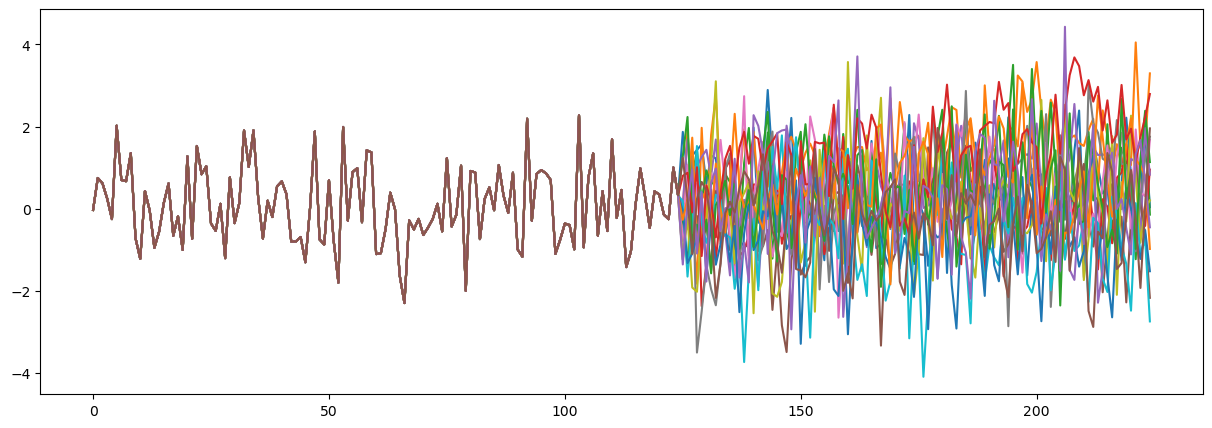

In [69]:
# plot combined_df
plt.figure(figsize=(15, 5))
plt.plot(combined_df)

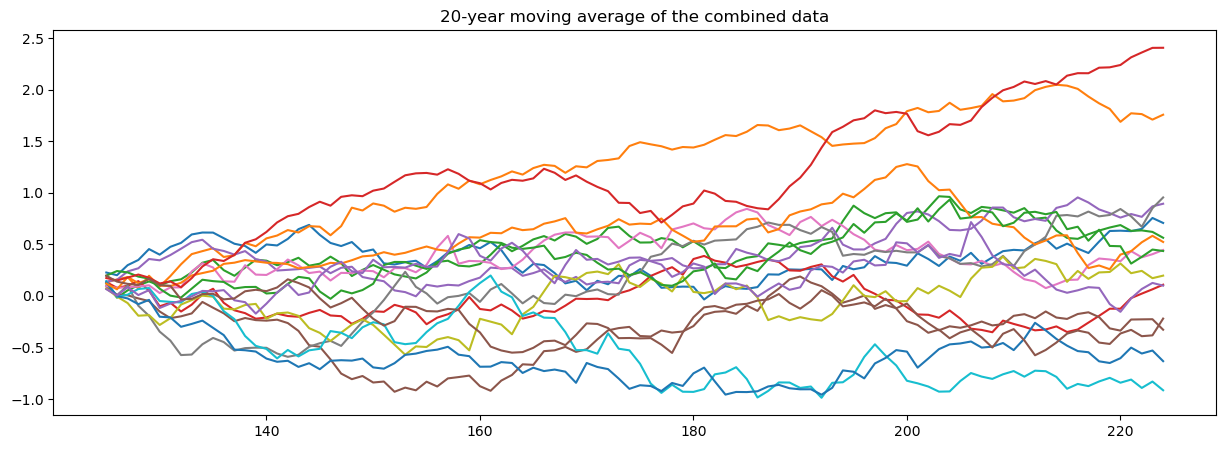

In [21]:
#visual combined_df 20 year moving average, and only plot the last 100 years
plt.figure(figsize=(15, 5))
plt.plot(combined_df.rolling(window=20).mean().iloc[-100:])
plt.title('20-year moving average of the combined data')
plt.show()
    

## compute non bayesian precipitation indicators

In [71]:
combined_df_20

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
125,0.227038,0.130823,0.119595,0.134447,0.139047,0.096896,0.094329,0.071539,0.072029,0.142755,0.131135,0.120027,0.197056,0.173539,0.065720,0.195566
126,0.200955,0.159860,-0.016913,0.078232,0.156298,0.010043,0.079972,0.007107,-0.005974,-0.007151,-0.002263,0.064339,0.241327,0.149898,0.004030,0.139061
127,0.298399,0.182772,0.054119,0.099225,0.237733,0.006138,0.083305,0.101601,-0.069137,0.012331,-0.024045,0.183549,0.227998,0.178165,0.084652,0.116805
128,0.348658,0.070188,0.103687,0.143675,0.268021,-0.024032,0.092344,-0.094733,-0.191510,0.067320,-0.079751,0.123893,0.187308,0.207284,0.008830,0.107172
129,0.454121,0.195780,0.140499,0.052316,0.358080,-0.049455,0.102944,-0.192569,-0.185694,0.076647,-0.038100,0.162196,0.168091,0.176808,0.056302,0.166903
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
220,0.632377,1.687254,0.686599,-0.123662,0.759297,-0.336012,0.336513,0.842355,0.314340,-0.840768,-0.603218,0.400688,0.481476,2.237956,-0.153615,-0.363948
221,0.627719,1.769970,0.630395,-0.020847,0.793854,-0.228529,0.434028,0.771187,0.220480,-0.810497,-0.500784,0.433697,0.313554,2.312187,-0.023506,-0.328551
222,0.649961,1.762042,0.635147,0.022537,0.766519,-0.226910,0.374406,0.670200,0.242997,-0.891392,-0.557877,0.519958,0.378995,2.359046,0.067269,-0.390009
223,0.755437,1.708676,0.620549,0.064311,0.867985,-0.225578,0.404506,0.849986,0.172071,-0.829627,-0.528914,0.582681,0.449496,2.403951,0.126015,-0.381919


Text(0.5, 1.0, '20-year moving std of the combined data')

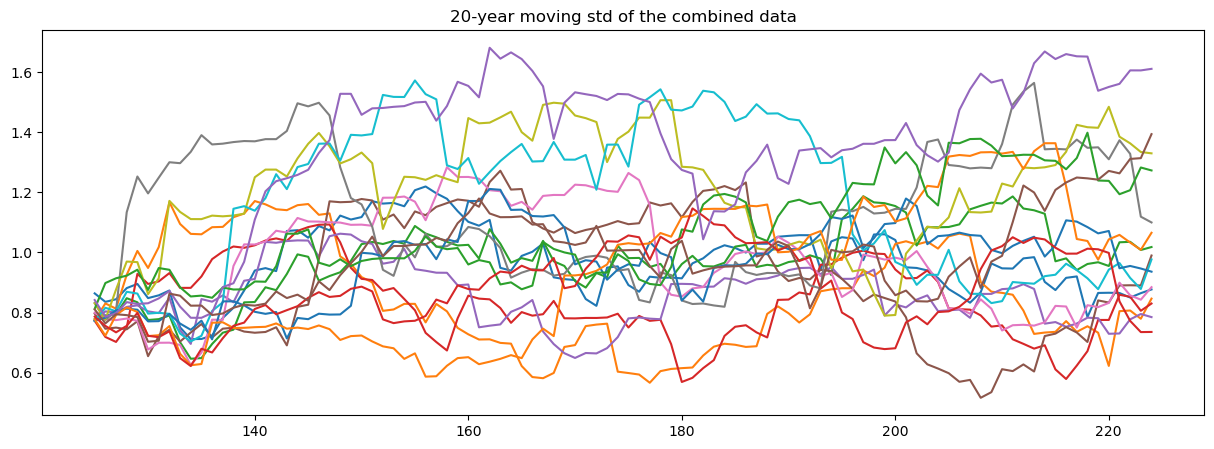

In [70]:
#compute 20-year moving average and standard deviation
combined_df_20 = combined_df.rolling(window=20).mean().iloc[-100:]
combined_df_20_std = combined_df.rolling(window=20).std().iloc[-100:]
# plot std
plt.figure(figsize=(15, 5))
plt.plot(combined_df_20_std)
plt.title('20-year moving std of the combined data')

-0.9867996965 1.77354193161


Text(0.5, 1.0, 'Normalized 20-year moving average of the cmip5 precipitation')

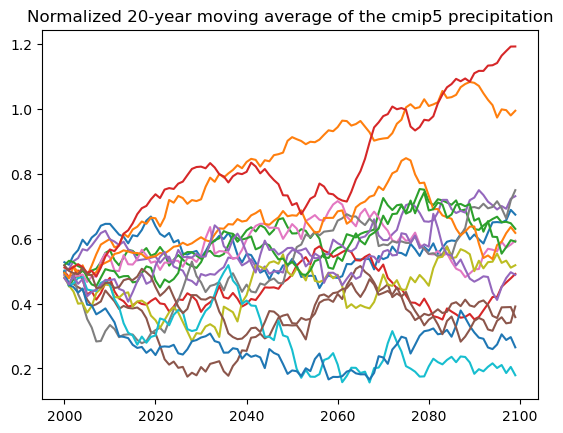

In [23]:
# normalize the data
min_value = combined_df_20.iloc[:].min().min()
max_value = combined_df_20.iloc[:].quantile(0.8).max()
print(min_value, max_value)
# Normalize the data to the range [0, 1]
min_value = -1.5
normalized_mean = (combined_df_20 - min_value) / (max_value - min_value)
for i in range(len(combined_df_20.columns)):
    plt.plot(np.arange(2000, 2100),normalized_mean.iloc[:,i])
plt.title('Normalized 20-year moving average of the cmip5 precipitation')

0.5167647510119935 1.552693911835446


Text(0.5, 1.0, 'Normalized 20-year moving std of the cmip5 precipitation')

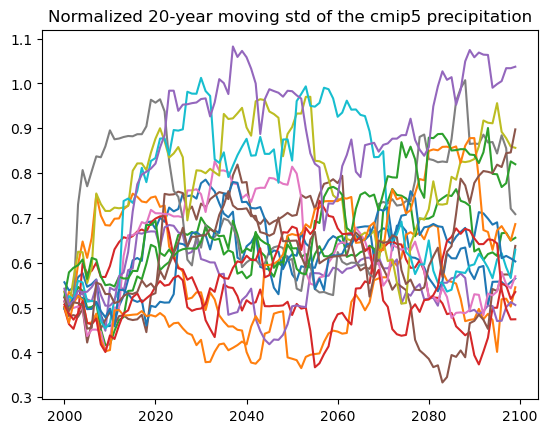

In [24]:
#normalize std
min_value = combined_df_20_std.iloc[:].min().min()
max_value = combined_df_20_std.iloc[:].quantile(0.8).max()
print(min_value, max_value)
# Normalize the data to the range [0, 1]
min_value = 0
normalized_std = (combined_df_20_std - min_value) / (max_value - min_value)
for i in range(len(combined_df_20_std.columns)):
    plt.plot(np.arange(2000, 2100),normalized_std.iloc[:,i])
plt.title('Normalized 20-year moving std of the cmip5 precipitation')


In [25]:
normalized_mean.reset_index(drop=True, inplace=True)
normalized_std.reset_index(drop=True, inplace=True)
normalized_mean

,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,0.527575,0.498183,0.494753,0.499290,0.500695,0.487819,0.487035,0.480073,0.480223,0.501828,0.498278,0.494885,0.518416,0.511232,0.478295,0.517961
1,0.519607,0.507053,0.453053,0.482118,0.505965,0.461287,0.482649,0.460390,0.456394,0.456035,0.457528,0.477874,0.531940,0.504010,0.459450,0.500699
2,0.549374,0.514052,0.474752,0.488530,0.530842,0.460094,0.483667,0.489256,0.437099,0.461986,0.450874,0.514290,0.527868,0.512645,0.484079,0.493901
3,0.564727,0.479660,0.489894,0.502109,0.540094,0.450878,0.486429,0.429280,0.399717,0.478784,0.433857,0.496066,0.515438,0.521540,0.460917,0.490958
4,0.596944,0.518026,0.501139,0.474201,0.567605,0.443112,0.489666,0.399393,0.401493,0.481633,0.446580,0.507767,0.509568,0.512230,0.475418,0.509205
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.651397,0.973641,0.667961,0.420443,0.690169,0.355574,0.561017,0.715541,0.554244,0.201382,0.273948,0.580621,0.605300,1.141869,0.411293,0.347041
96,0.649975,0.998909,0.650792,0.451851,0.700725,0.388408,0.590806,0.693801,0.525572,0.210629,0.305240,0.590705,0.554004,1.164545,0.451039,0.357854
97,0.656769,0.996487,0.652244,0.465104,0.692375,0.388903,0.572593,0.662952,0.532450,0.185917,0.287799,0.617056,0.573994,1.178860,0.478769,0.339080
98,0.688990,0.980185,0.647784,0.477865,0.723371,0.389310,0.581788,0.717873,0.510783,0.204785,0.296647,0.636216,0.595531,1.192577,0.496714,0.341551


In [26]:
# save as csv
normalized_mean.to_csv(f'{result_loc}/cmip_prep_mean.csv', index=False)
normalized_std.to_csv(f'{result_loc}/cmip_prep_std.csv', index=False)

**Monthly KNN**

In [27]:
## generate monthly data using KNN
#read and process monthly data
file_monthly = 'Mombas_6x6_monthly_precip.txt'   # use as virtual monthly observations
data_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/synthetic generator/data'
monthly_df = pd.read_csv(f'{data_loc}/{file_monthly}')
year = np.repeat(np.arange(1850, 2301), 12)
monthly_df['year']= year
# filter, only keep 1860 - 2275
monthly_df= monthly_df[(monthly_df['year'] >= 1860) & (monthly_df['year'] <= 2274)].reset_index(drop=True)

#general setting
model_index = 1  # first gcm as virtual monthly observations to extract monthly pattern
nsample = 600 # 

# "bcc_csm1_1"
hist_std = 0.218338
hist_mean =  3.895907

#historical monthly data : year 1860 - 1950 
monthly_obs = np.array(monthly_df.iloc[:,model_index])[:12 * (1950 - 1860 + 1)]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


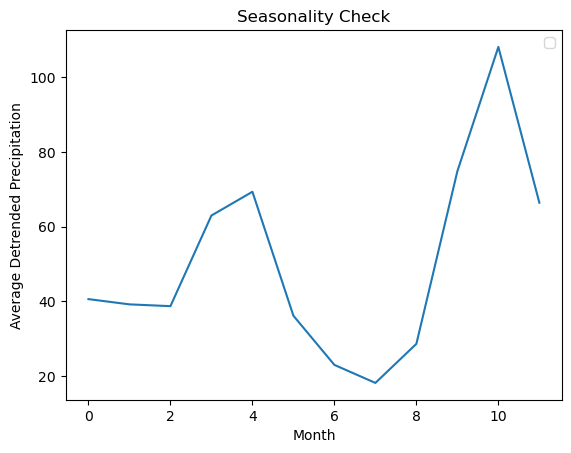

In [41]:
# monthly KNN

synthetic_data = YrDf_df.iloc[:,1:]
hist_std = 0.2
hist_mean = 3.8
np.random.seed(66)
monprep_lists = []
n_models = synthetic_data.shape[1]
Nyears = synthetic_data.shape[0]


# init result matrix
monQsyn_mat = np.zeros((Nyears *12, n_models))  # N years * 12 months
de_monQsyn_mat = np.zeros((Nyears*12, n_models))  # Detrended monthly synthetic data


 # De-standardize and transform to exponential scale
annQsyn_df =  synthetic_data.iloc[:, :] * hist_std + hist_mean
annQsyn_df = np.exp(annQsyn_df)

for i in range(n_models):

    annQsyn = annQsyn_df.iloc[:, i].values
    monQsyn, de_monQsyn = ut_knn.month_knn(annQsyn, monthly_obs, i, 0.8)

    # Save results
    monQsyn_mat[:, i] = monQsyn
    de_monQsyn_mat[:, i] = de_monQsyn

    # Sample test for seasonality
    if i ==2: 
        seasonality = np.mean(de_monQsyn.reshape(-1, 12), axis=0)
        plt.plot(seasonality)
        plt.title("Seasonality Check")
        plt.xlabel("Month")
        plt.ylabel("Average Detrended Precipitation")
        plt.legend()
        plt.show()

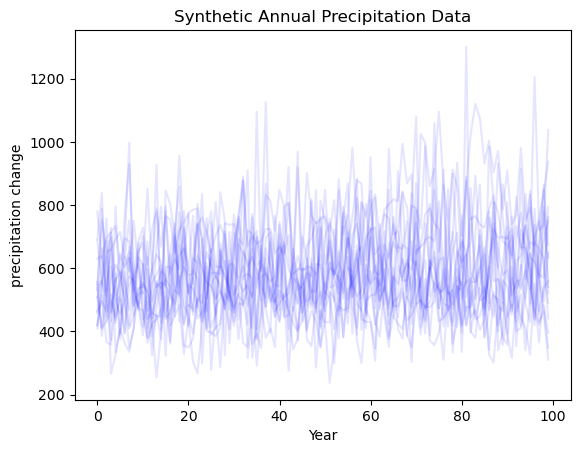

In [44]:
#plot annual precipitation data by summing every 12 month data
for i in np.arange(0,16):
    plt.plot(np.sum(monQsyn_mat[:, i].reshape(-1, 12), axis=1), color='blue', alpha=0.1)
plt.xlabel('Year')
plt.ylabel('precipitation change')
plt.title('Synthetic Annual Precipitation Data')
plt.show()

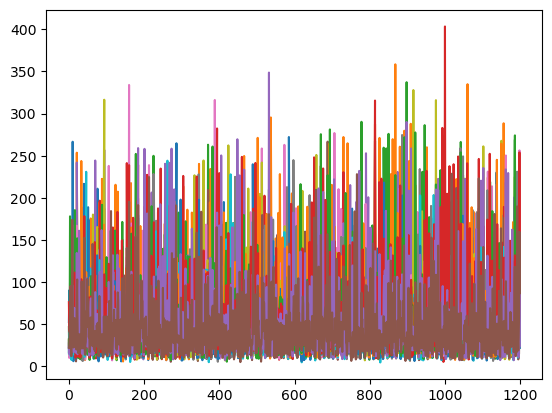

In [46]:
for i in range(16):
    plt.plot(monQsyn_mat[:,i])

In [47]:
monQsyn_mat.shape
sample_result_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization/data/Annual_GPR'
# Save the monthly synthetic data
df_mon = pd.DataFrame(monQsyn_mat)
file_name = f'cmip_month_prep.csv'
df_mon.to_csv(f'{sample_result_loc}/{file_name}', index=False)  # Set index=False if you don't want row numbers in your CSV file

*inflow indicators*

In [48]:
# from cmip_runoff.csv, compute inflow_indicators
result_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization/data/Annual_GPR'
select_inflow = 'cmip_runoff.csv'
inflows = pd.read_csv(f'{result_loc}/{select_inflow}', header = None).T/12
inflows

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,2.588091,6.019303,5.186662,3.306669,5.160347,3.195120,8.681970,5.220908,4.260973,2.306513,5.893585,4.451756,5.194195,9.263969,3.057336,5.187430
1,3.201029,4.152420,3.150704,2.738135,4.795884,3.563003,4.137473,4.458792,3.064844,6.177462,7.632163,2.997482,3.351837,6.313702,2.170520,3.712109
2,3.161763,3.586270,2.409951,2.613286,3.922681,2.886708,3.084477,5.442243,2.802107,4.110865,5.840220,2.590638,3.403809,4.942425,1.847789,4.100205
3,5.966025,6.129405,2.982355,4.210317,5.123576,3.115724,7.141649,4.892866,3.643969,7.089401,6.796131,2.738386,11.483969,4.702788,2.043333,5.200689
4,5.176871,6.369247,2.944151,3.523321,4.331278,4.337715,5.471406,4.187750,3.449342,4.638646,6.281413,6.133942,12.025626,5.784929,3.003053,7.863127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,2.245285,4.256156,2.063992,4.174401,3.069563,1.557769,2.335778,3.531439,3.651437,1.845239,2.063502,2.332863,4.475185,3.226838,2.150035,4.585159
1196,1.783750,3.879686,2.983538,3.988935,2.702829,1.276121,3.482431,4.130352,2.670849,1.643203,2.124249,2.787929,3.444820,3.719761,1.556930,3.799148
1197,2.687809,11.115981,4.159731,4.051544,4.139513,1.330492,3.622188,6.696954,4.566034,2.075653,2.118657,3.051723,4.122805,5.706432,1.912745,4.553009
1198,4.465283,16.484410,7.931030,6.588138,10.174799,4.441988,17.537813,6.954039,7.567265,4.300788,6.114366,3.725912,6.161777,18.543132,7.133190,10.530811


2.9447877647644405 7.031601021367128


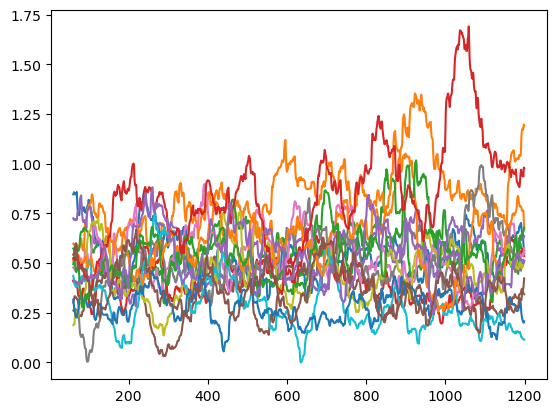

In [50]:
#compute previous 5 year rolling mean
rolling_means = inflows.rolling(window=60, min_periods=1).mean()
#plt.plot(rolling_means.iloc[:,5])
# Compute the minimum and maximum values across the DataFrame
min_value = rolling_means.iloc[60:].min().min()
max_value = rolling_means.iloc[60:].quantile(0.8).max()

print(min_value, max_value)
# Normalize the data to the range [0, 1]
normalized_inflows = (rolling_means - min_value) / (max_value - min_value)
for i in np.arange(0, 16):
    plt.plot(normalized_inflows.iloc[60:,i])

In [51]:
#save in a csv in data
normalized_inflows.to_csv(f'{result_loc}/cmip_inflow_indicators.csv', index=False)

**Bayes Indicators**

In [61]:
# GPR sequential learning using synthetic data
def GPR_update(GCM_data, obs,test_data,  Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3, sigma_n, with_noise=True):

    Nyears = 400  # length of the whole study period (1875-2275)
    # Init null matrix with zeros for records of post_mu, post_std in each update, for each synthetic realization
    mu_mat = np.zeros((Nyears, Ncycles))
    std_mat = np.zeros((Nyears, Ncycles))

    updated_obs = np.copy(obs[:Nobs])


    for i in range(Ncycles):
        #print(f'Cycle {i+1} of {Ncycles}')
    

        updated_Nobs = Nobs + Nyears_per_cycle * i
        updated_obs = np.concatenate((obs[:Nobs], test_data[:Nyears_per_cycle * i]), axis=0)

        # GPR update
        prior_mu, prior_cov, post_mu, post_cov, lml = ut.GPR_func(updated_obs, updated_Nobs, GCM_data, sigma1, sigma2,
                                                                sigma3, sigma_n, use_cholesky=True)
        mu_mat[:, i] = post_mu
        if with_noise:
            std_mat[:, i] = np.sqrt(np.diag(post_cov) + sigma_n)
        else:
            std_mat[:, i] = np.sqrt(np.diag(post_cov))

    return mu_mat, std_mat

In [62]:

def compute_mu_std(test_data, YrDf_cmip5, smoothed_50yrDf_cmip5,  Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3, stdObs, with_noise):


    # init result matrix
    n_models = test_data.shape[1]
    mu_gcm = np.zeros((n_models, 400, Ncycles))
    std_gcm = np.zeros((n_models, 400, Ncycles))

    for i in range(n_models):
        #print(f'model {i+1} of {n_models}')

        Nobs_2000 = np.where(YrDf_cmip5["years"] == 2000)[0][0] 
        #obs = np.concatenate([YrDf_cmip5.iloc[:Nobs_2000 ,1].values.tolist(), test_data[:5,i].tolist()])   # add oosgcm pre1950 data and test data 1950-2000 data together as my intial observations
        obs = YrDf_cmip5.iloc[:Nobs_2000 ,1].values.tolist()
        column_indices = [i for i in range(smoothed_50yrDf_cmip5.shape[1]) if i != 0 and i != 1]
        GCM_data = pd.DataFrame(smoothed_50yrDf_cmip5.iloc[:, column_indices])
        

        mu_mat, std_mat = GPR_update(GCM_data, obs, test_data[:,i], Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3,stdObs, with_noise)
        mu_gcm[i] = mu_mat
        std_gcm[i] = std_mat
        

    return mu_gcm, std_gcm

In [63]:
Nyears_per_cycle = 2
Ncycles = int(100/Nyears_per_cycle)
data = YrDf_df.iloc[:,1:] # first col is years, later 16 cols is 16 GCM


sigma1, sigma2, sigma3 = 0.25, 0.95, 0  # Hyperparameters for annual data
Nobs = np.where(YrDf["years"] == 2000)[0][0] 

stdObs = 0.85

mu_test, std_test = compute_mu_std(np.array(data), YrDf, smoothed_50yrDf_cmip5,  Nobs, Nyears_per_cycle, Ncycles, sigma1, sigma2, sigma3, stdObs, with_noise=False)

mu_test.shape

(16, 400, 50)

In [82]:
result_loc = '/Users/mofanz/Documents/OneDrive - Stanford/research/4. 2024/project/Bayesian DPS/coding/Bayesian DPS optimization/data/Annual_GPR'
file_name = f'cmip_bayes_indicators.npz'
np.savez(f'{result_loc}/{file_name}', mu=mu_test, std=std_test)

In [78]:
## test normalization

def extract_climate_indicators(cliamte_means, cliamte_stds, t, Nyears_per_cycle, normalized = True):

        # input. cliamte_means is i slice of loaded_mu, 2d matrix for ith simulation
        # input. t: simulation time step in months.
        # output: climate indicators: mean(t), mean(t+50), std(t+50), mean(2100), std(2100)

        # get the year index
        T = int(t/12)
        #which update cycle
        cycle_index = int(T/ Nyears_per_cycle)    

        #convert year index in cliamte_means file (climate_means file year start from 1875)
     
        T_convert = T + 125
        mean_t = climate_mean_avg(cliamte_means, 0 ,T_convert, cycle_index)
        std_t = cliamte_stds[T_convert, cycle_index]
        mean_t_50 =climate_mean_avg(cliamte_means, 50, T_convert, cycle_index)
        std_t_50 = cliamte_stds[T_convert + 50, cycle_index]

        #### indicators at year 2100
        years = np.arange(1875, 2275)
        year2100 =np.where(years ==2100)[0][0]
        mean_2100 = climate_mean_avg(cliamte_means, 0 , year2100, cycle_index)
        std_2100 = cliamte_stds[year2100, cycle_index]

        #normalize
          #normalized
        norm_mean_t = normalize_climate_indicators(mean_t, mean = True)
        norm_std_t = normalize_climate_indicators(std_t, mean = False)
        norm_mean_t_50 = normalize_climate_indicators(mean_t_50, mean = True)
        norm_std_t_50 = normalize_climate_indicators(std_t_50 , mean = False)
        norm_mean_2100 = normalize_climate_indicators(mean_2100, mean = True)
        norm_std_2100 = normalize_climate_indicators(std_2100, mean= False)

        if normalized ==True:
            return [norm_mean_t, norm_std_t,norm_mean_t_50, norm_std_t_50,norm_mean_2100, norm_std_2100]  
        else:
            return [mean_t, std_t, mean_t_50, std_t_50, mean_2100, std_2100] 

def climate_mean_avg(climate_means, t_plus,T_convert, cycle_index ):

    T = T_convert + t_plus
    means = [climate_means[T, cycle_index]]
    
    if T_convert - 9 >=0:
        means.append(climate_means[T - 1, cycle_index])
        means.append(climate_means[T - 2, cycle_index])
        means.append(climate_means[T- 3, cycle_index])
        means.append(climate_means[T - 4, cycle_index])

    mean_avg = np.mean(means)

    return mean_avg

def normalize_climate_indicators(indicator, mean = True ):

    if mean == True:
  

        min_value = - 1.2
        max_value = 1.5
    
    else:
      
        
        min_value = 0.3
        max_value = 0.6

    normalized_indicator = (indicator - min_value) / (max_value - min_value)
    return normalized_indicator

In [79]:
num_models = np.array(data).shape[1]
num_years = 100  # Number of years for which data is generated

# Pre-allocate numpy arrays for each set of indicators
mean_ts = np.zeros((num_years, num_models))
std_ts = np.zeros((num_years, num_models))
mean_t50s = np.zeros((num_years, num_models))
std_t50s = np.zeros((num_years, num_models))
mean_t2100 = np.zeros((num_years, num_models))
std_t2100 = np.zeros((num_years, num_models))


for model_idx in range(num_models):
    for year_idx in range(num_years):
        t = year_idx * 12  # Assumes t is indexed by month, and you pick the first month of each year
        # Extract indicators
        indicators = extract_climate_indicators(mu_test[model_idx,...], std_test[model_idx,...], t, Nyears_per_cycle,normalized=True)
        mean_ts[year_idx, model_idx] = indicators[0]
        std_ts[year_idx, model_idx] = indicators[1]
        mean_t50s[year_idx, model_idx] = indicators[2]
        std_t50s[year_idx, model_idx] = indicators[3]
        mean_t2100[year_idx, model_idx] = indicators[4]
        std_t2100[year_idx, model_idx] = indicators[5] 

Text(0.5, 1.0, 'Normalized std at year 2100')

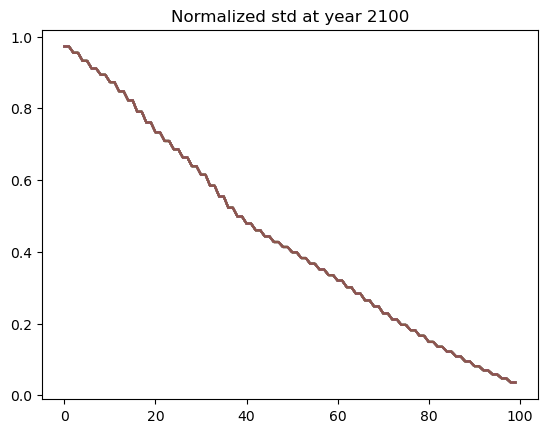

In [81]:
plt.plot(std_t2100[:,:])
plt.title('Normalized std at year 2100')

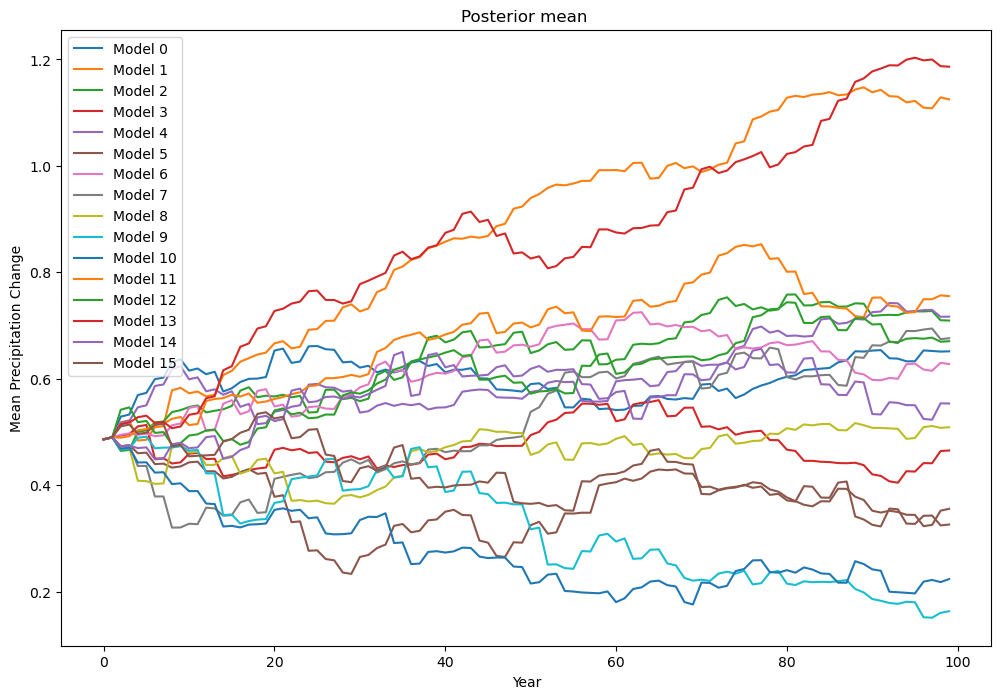

In [80]:
plt.figure(figsize=(12, 8))
for i in range(num_models):
    plt.plot(mean_ts[:, i], label=f'Model {i}')
plt.xlabel('Year')
plt.ylabel('Mean Precipitation Change')
plt.title('Posterior mean ')
plt.legend()
plt.show()

**Not used**

In [89]:

#filter year from 1980 to 2100 and compute the 20-year moving average
YrDf_ma = YrDf[(YrDf['years']>=1980) & (YrDf['years']<=2100)]
for i in range(16):
    YrDf_ma.iloc[:,i+1] = YrDf_ma.iloc[:,i+1].rolling(window=20).mean()
#reset index
YrDf_ma = YrDf_ma.reset_index(drop=True)
YrDf_ma

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116,2096,0.627719,1.769970,0.630395,-0.020847,0.793854,-0.228529,0.434028,0.771187,0.220480,-0.810497,-0.500784,0.433697,0.313554,2.312187,-0.023506,-0.328551
117,2097,0.649961,1.762042,0.635147,0.022537,0.766519,-0.226910,0.374406,0.670200,0.242997,-0.891392,-0.557877,0.519958,0.378995,2.359046,0.067269,-0.390009
118,2098,0.755437,1.708676,0.620549,0.064311,0.867985,-0.225578,0.404506,0.849986,0.172071,-0.829627,-0.528914,0.582681,0.449496,2.403951,0.126015,-0.381919
119,2099,0.707390,1.756223,0.563749,0.108931,0.893457,-0.327310,0.445004,0.954435,0.196817,-0.913969,-0.632023,0.522995,0.435292,2.404792,0.100018,-0.219440


In [90]:
#value at years = 2000 of YrDf_ma
YrDf_ma[YrDf_ma['years']==2000]

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
20,2000,0.227038,0.342525,0.203262,-0.060566,0.108059,-0.791031,0.035447,-0.434711,-0.21831,0.075374,-0.175925,0.120847,0.320524,0.349251,-0.21411,-0.173855


In [79]:
# adjust by substracting the value at years = 2000
YrDf_ma_adj = YrDf_ma.copy()
for i in range(16):
    YrDf_ma_adj.iloc[:,i+1] = YrDf_ma_adj.iloc[:,i+1] - YrDf_ma[YrDf_ma['years']==2000].iloc[:,i+1].values[0]
# filter year from 2000 to 2100
YrDf_ma_adj = YrDf_ma_adj[(YrDf_ma_adj['years']>=2000) & (YrDf_ma_adj['years']<=2100)]
YrDf_ma_adj = YrDf_ma_adj.reset_index(drop=True)
YrDf_ma_adj

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,2000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2001,-0.026083,0.138248,-0.133319,0.071410,0.123065,0.039265,0.092999,0.050169,-0.098092,-0.070217,0.010547,-0.049488,-0.010445,-0.021996,-0.011080,0.014548
2,2002,0.071361,0.146512,-0.217717,0.075828,0.101249,0.117575,0.027939,0.168771,-0.170307,-0.194765,-0.058401,0.177071,-0.094846,-0.051348,0.008166,0.030973
3,2003,0.121620,0.055395,-0.156413,0.096078,0.152230,0.256718,0.045737,-0.064167,-0.297691,-0.100314,-0.086861,0.149428,-0.132475,0.107885,-0.039536,0.070591
4,2004,0.227083,0.101154,-0.201487,0.037416,0.139458,0.243719,0.012587,-0.253870,-0.347917,-0.087703,-0.120916,0.115437,-0.235504,0.043375,-0.017309,0.047736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,2096,0.400681,1.427444,0.427133,0.039720,0.685795,0.562502,0.398581,1.205899,0.438790,-0.885872,-0.324859,0.312849,-0.006970,1.962937,0.190604,-0.154696
97,2097,0.422923,1.419517,0.431884,0.083103,0.658460,0.564121,0.338958,1.104912,0.461306,-0.966767,-0.381951,0.399111,0.058471,2.009795,0.281379,-0.216154
98,2098,0.528399,1.366151,0.417287,0.124877,0.759926,0.565452,0.369059,1.284698,0.390380,-0.905002,-0.352989,0.461834,0.128972,2.054700,0.340124,-0.208064
99,2099,0.480352,1.413698,0.360487,0.169497,0.785398,0.463720,0.409557,1.389147,0.415126,-0.989344,-0.456097,0.402147,0.114768,2.055541,0.314128,-0.045585


Text(0.5, 0, 'Year')

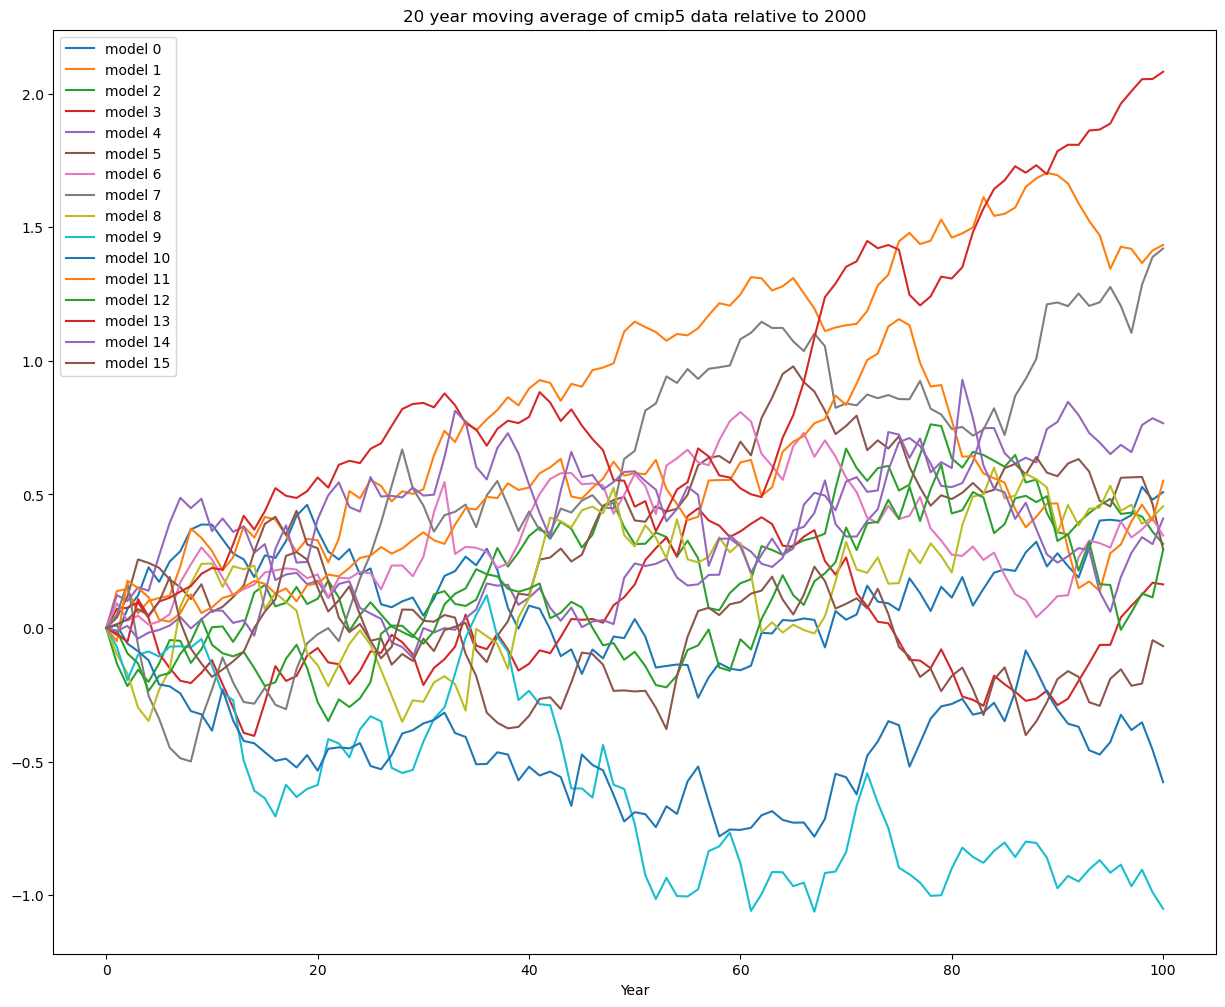

In [80]:
#plot the adjusted data in one figure
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(YrDf_ma_adj.iloc[:,i+1], label = f'model {i}')
plt.legend()
plt.title('20 year moving average of cmip5 data relative to 2000')
plt.xlabel('Year')


In [81]:
# substract YrDf_ma at 2000 from YrDf
# filter YrDf from 2000 to 2100
YrDf_adj = YrDf.copy()
for i in range(16):
    YrDf_adj.iloc[:,i+1] = YrDf_adj.iloc[:,i+1] - YrDf_ma[YrDf_ma['years']==2000].iloc[:,i+1].values[0]
YrDf_adj = YrDf_adj[(YrDf_adj['years']>=2000) & (YrDf_adj['years']<=2100)]
YrDf_adj = YrDf_adj.reset_index(drop=True)
YrDf_adj

,years,model_0,model_1,model_2,model_3,model_4,model_5,model_6,model_7,model_8,model_9,model_10,model_11,model_12,model_13,model_14,model_15
0,2000,1.643638,-0.396154,-0.481450,0.079431,0.002796,0.058869,-0.818947,-0.804591,-1.011185,0.109638,0.128537,-0.390381,0.950516,0.451447,-1.141578,1.415086
1,2001,0.598756,1.585678,-1.585971,0.283712,1.584422,0.401421,1.024858,0.493522,0.005686,-1.726041,-1.144582,0.112846,1.912353,0.525385,0.327760,0.391204
2,2002,1.067790,-0.538338,0.563347,-0.173626,0.866579,0.058881,-0.622832,1.670547,-1.698994,-0.339783,-0.913764,1.609298,-1.241158,-0.437954,1.172515,-0.925300
3,2003,1.205131,-2.167225,1.215074,1.376552,0.924693,0.614613,0.572325,-3.064982,-1.802155,1.451404,-0.511200,-0.886995,-0.707348,0.660102,-0.875358,0.408181
4,2004,1.340219,1.627305,-0.009020,-2.308622,1.151116,-0.259421,-0.365469,-2.064019,-0.207392,-0.430849,0.466930,0.103218,-1.246858,-1.500773,0.621559,0.826469
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,2096,0.515380,3.705764,-1.430985,1.647802,1.032958,2.017095,1.893451,-0.601054,0.989625,0.060151,-0.512507,1.080487,-1.297430,0.776653,1.543709,-0.095332
97,2097,0.085344,1.135982,0.810446,0.374135,-0.831023,0.899117,0.364815,0.718011,-0.609073,-1.188609,-1.045841,0.925074,0.912803,1.393331,1.885774,-1.753768
98,2098,1.642747,1.245581,2.087444,-0.357247,1.855640,0.164266,0.270312,1.641534,0.237030,-0.825221,-0.343911,0.684744,2.063743,1.887807,0.895744,0.274869
99,2099,-0.188913,2.951982,-0.346230,1.012426,0.722302,-1.376739,1.638781,2.188028,0.423464,-2.817094,-1.344872,-1.098665,0.815775,2.443187,-0.237306,2.129617


Text(0.5, 0, 'Year')

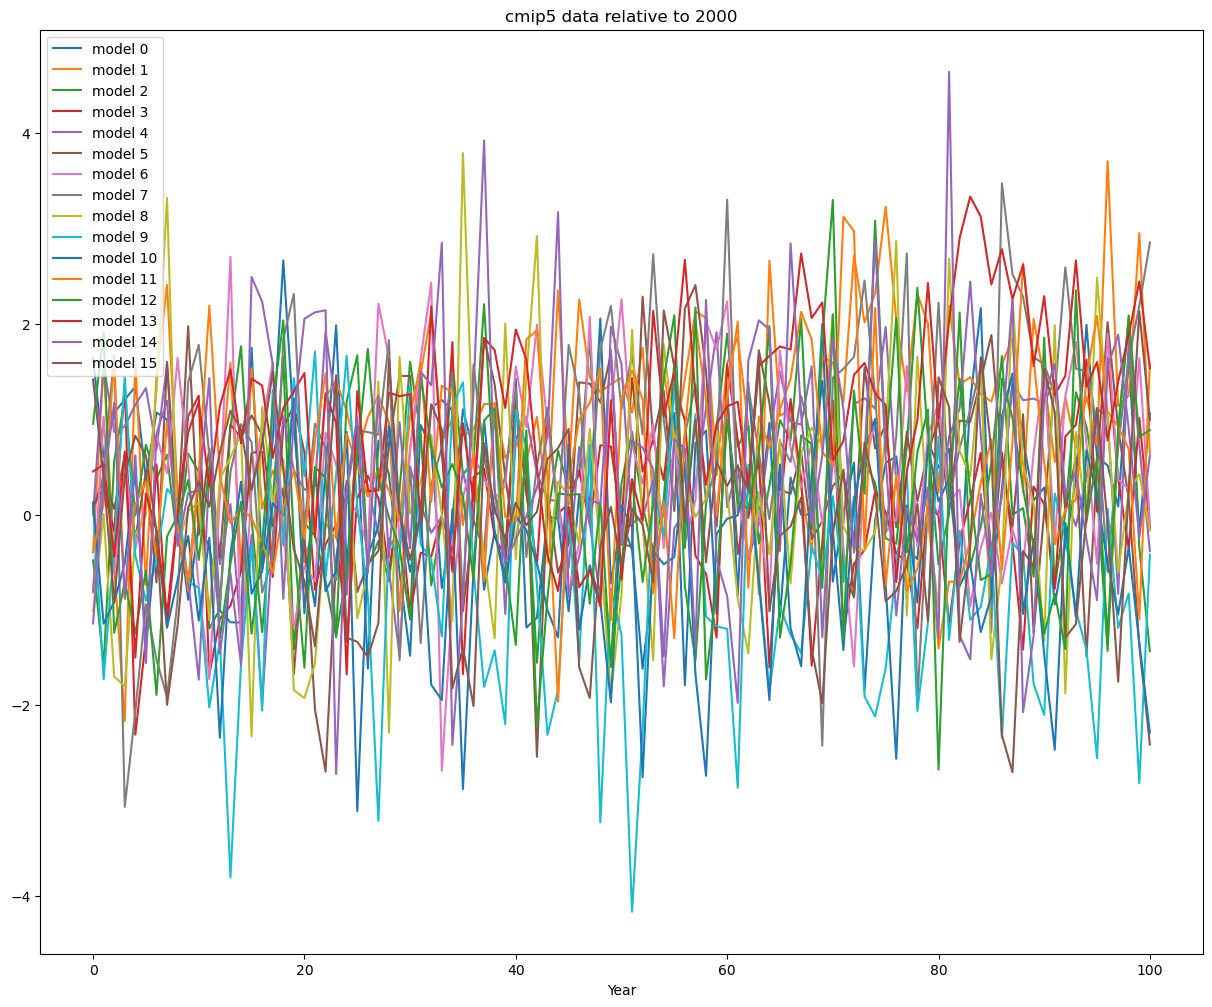

In [82]:
# plot
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(YrDf_adj.iloc[:,i+1], label = f'model {i}')
plt.legend()
plt.title('cmip5 data relative to 2000')
plt.xlabel('Year')


Text(0.5, 0, 'Year')

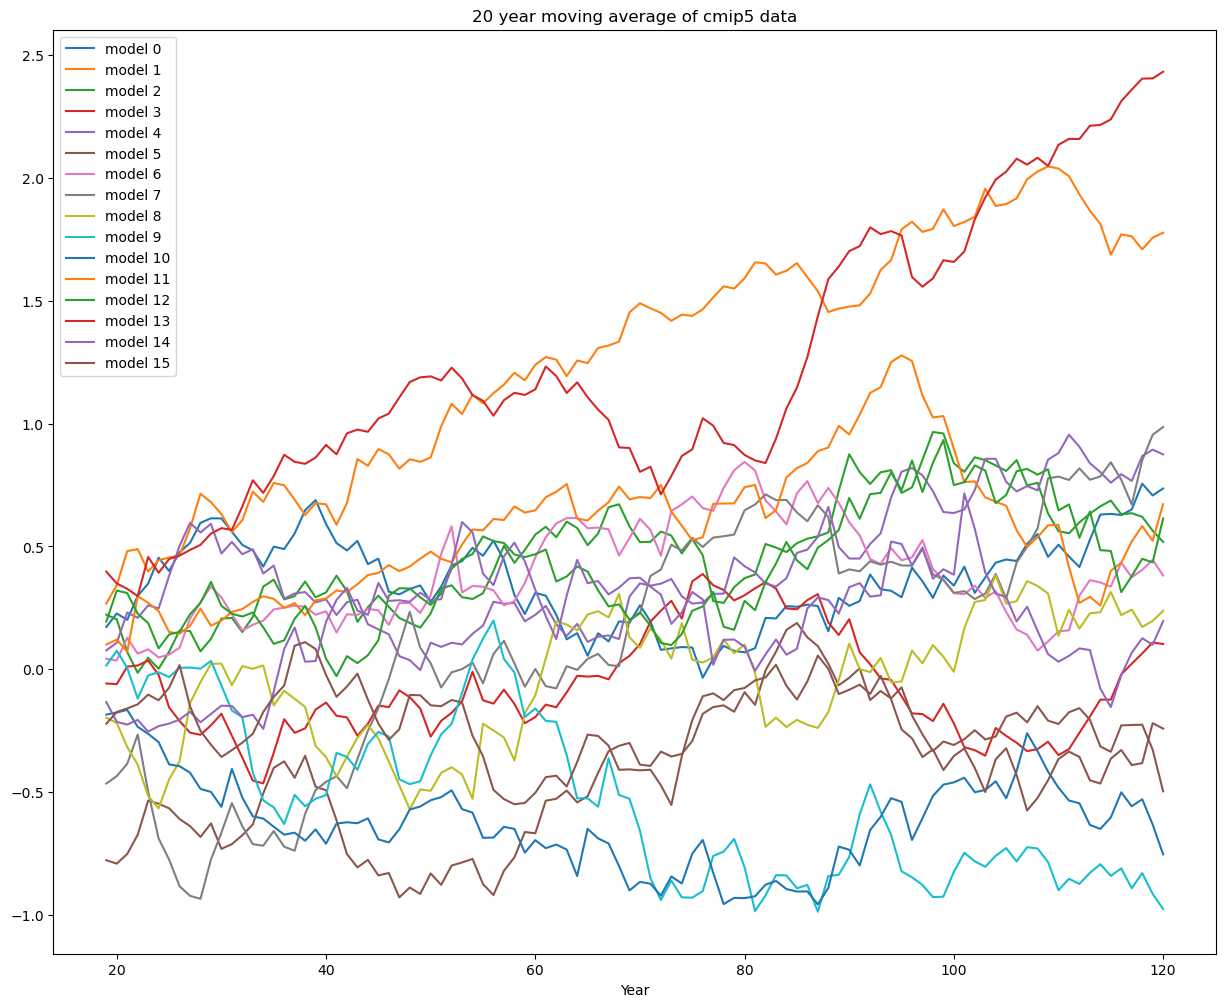

In [87]:
# plot YrDf 20 year moving average and plot 2000-2100
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(YrDf_ma.iloc[:,i+1], label = f'model {i}')
plt.legend()
plt.title('20 year moving average of cmip5 data')
plt.xlabel('Year')


Text(0.5, 0, 'Year')

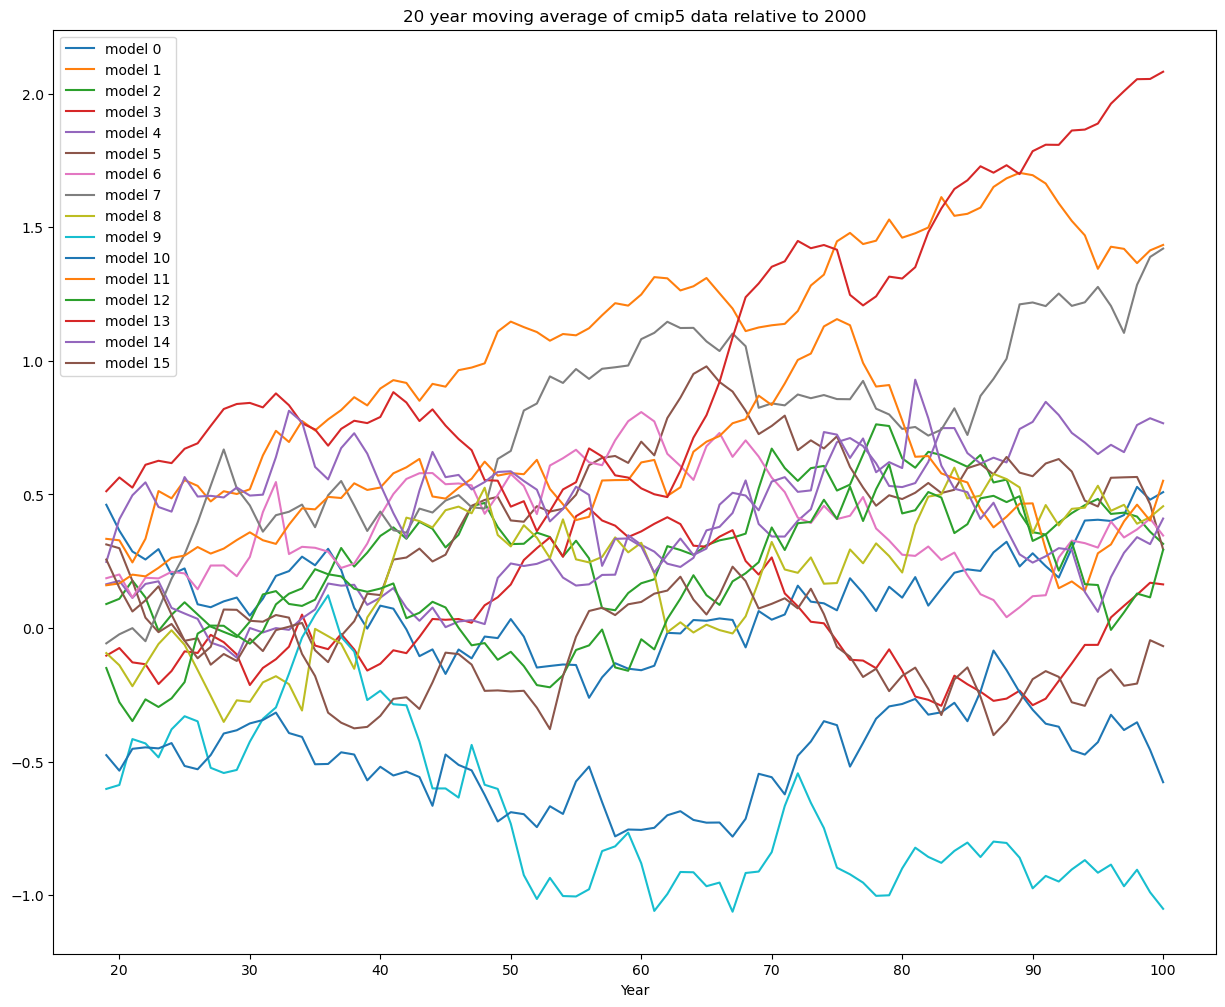

In [83]:
#plot YrDf_adj 20-year moving average
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(YrDf_adj.iloc[:,i+1].rolling(window=20).mean(), label = f'model {i}')
plt.legend()
plt.title('20 year moving average of cmip5 data relative to 2000')
plt.xlabel('Year')


Text(0.5, 0, 'Year')

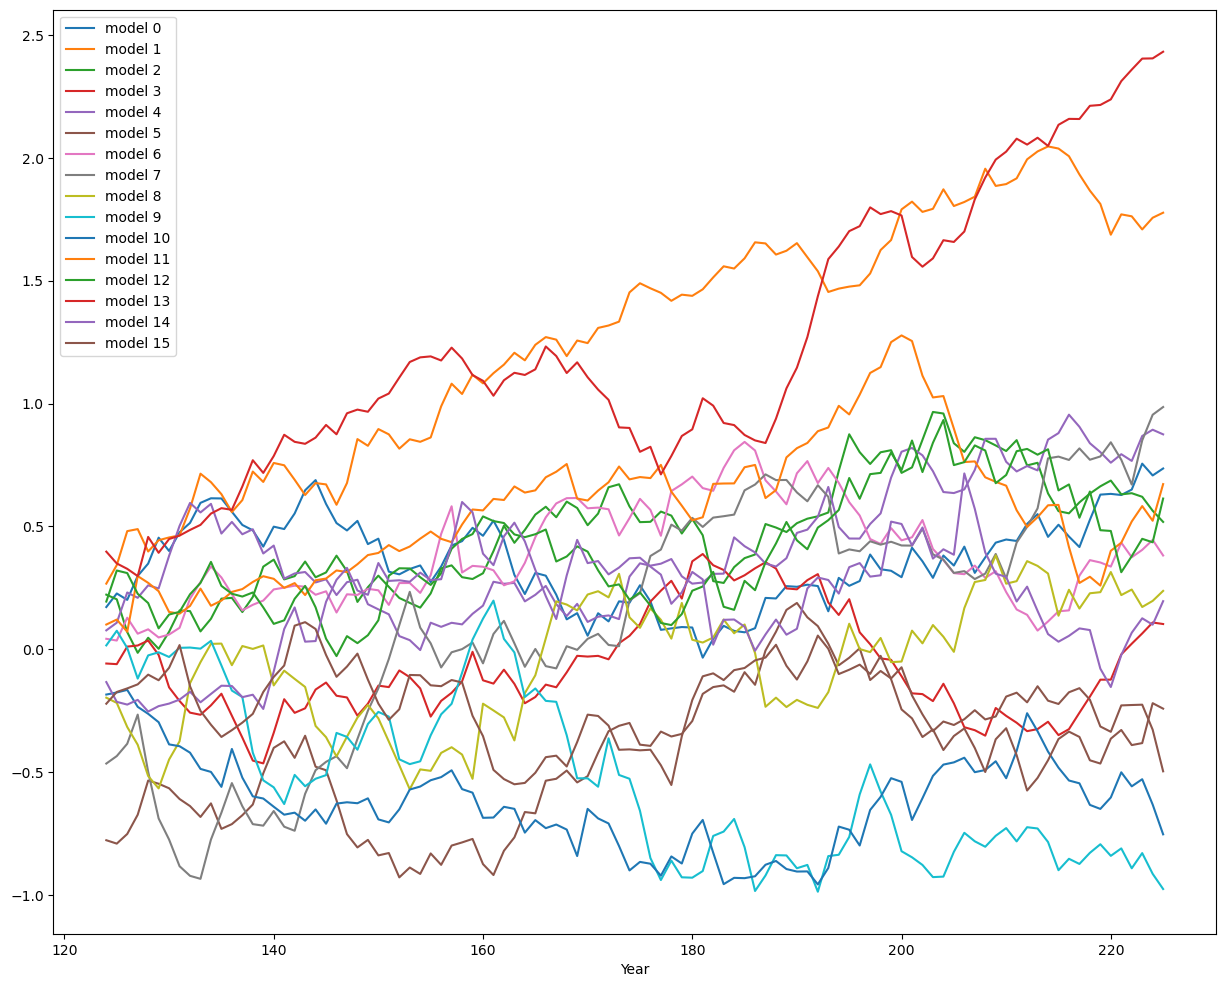

In [62]:
# plot YrDf_ma, x axis is year 2000-2099
# set figure size
plt.figure(figsize=(15, 12))
for i in range(16):
    plt.plot(YrDf_ma.iloc[:,i+1], label = f'model {i}')
plt.legend()

plt.xlabel('Year')

In [5]:
# compute std of each model
std = YrDf.std(axis = 0)
print(std)

years       29.011492
model_0      0.981611
model_1      0.984227
model_2      1.014287
model_3      0.870824
model_4      0.893953
model_5      0.992181
model_6      1.008180
model_7      1.252082
model_8      1.265870
model_9      1.229720
model_10     0.973655
model_11     1.002373
model_12     1.137139
model_13     1.045209
model_14     1.391170
model_15     1.056538
dtype: float64


In [34]:
# read Mombas monthly data
#read and process monthly data
file_monthly = 'Mombas_6x6_monthly_precip.txt'   # use as virtual monthly observations
monthly_df = pd.read_csv(f'{result_loc}/{file_monthly}')
year = np.repeat(np.arange(1850, 2301), 12)
monthly_df['year']= year
# filter, only keep 1860 - 2275
monthly_df= monthly_df[(monthly_df['year'] >= 1875) & (monthly_df['year'] <= 2274)].reset_index(drop=True)
monthly_df

,year,bcc_csm1_1,CanESM2,CESM1_CAM5,CSIRO_mk3L_1_2,CSIRO_MK3_6_0,CNRM_CM5,FGOALS_g2,GFDL_CM3,GISS_E2_H,GISS_E2_R,HadGEM2_ES,IPSL_CM5A_LR,IPSL_CM5A_MR,MIROC_ESM,MPI_ESM_LR,NorESM1_M
0,1875,66.568599,30.362434,56.464784,66.867940,16.639620,62.377143,71.660114,42.851431,115.037576,82.618930,78.934246,11.524045,58.262880,66.354453,79.190582,140.270180
1,1875,20.815274,83.522246,30.646297,143.569986,11.316592,64.059079,46.315489,11.411695,41.336314,147.259980,46.653475,19.868387,24.913641,70.357457,33.828180,15.313989
2,1875,53.008335,142.528884,4.548601,19.181055,15.777198,16.550524,35.878645,16.794008,38.194355,35.548489,57.182988,13.819106,48.308521,35.006482,13.036546,34.809472
3,1875,39.475659,77.412122,138.662493,60.192035,86.513176,88.898361,80.389710,17.721821,122.015803,155.344206,76.682400,90.105908,124.022426,62.598933,60.468528,86.185814
4,1875,35.471653,47.731497,203.336766,34.725899,7.912647,120.720875,160.057934,160.060969,210.416624,230.357324,138.118292,73.980724,89.016301,54.696947,18.219802,108.678463
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4795,2274,29.299359,15.626955,33.183686,0.527426,12.174202,50.555956,102.077541,29.801204,112.662467,100.935236,15.933935,48.143702,10.571638,12.288820,4.018576,28.260232
4796,2274,89.502262,28.364738,98.246105,1.241214,10.699923,101.832926,110.968598,32.960571,114.082451,122.246935,13.936874,14.485009,24.385350,26.309785,0.917586,33.164603
4797,2274,75.015908,61.943962,70.460832,7.727378,13.066395,104.160128,155.208996,81.332830,182.304719,221.102703,110.806568,26.951775,26.375206,68.226242,37.560935,27.088337
4798,2274,62.579236,252.360279,162.818137,136.832503,97.798495,257.840112,140.274368,168.613268,264.905247,203.473402,116.412978,9.278492,53.142413,136.300755,160.808476,97.640688


In [38]:
# compute annual mean
annual_df = monthly_df.groupby('year').mean().reset_index()
annual_df




,year,bcc_csm1_1,CanESM2,CESM1_CAM5,CSIRO_mk3L_1_2,CSIRO_MK3_6_0,CNRM_CM5,FGOALS_g2,GFDL_CM3,GISS_E2_H,GISS_E2_R,HadGEM2_ES,IPSL_CM5A_LR,IPSL_CM5A_MR,MIROC_ESM,MPI_ESM_LR,NorESM1_M
0,1875,48.877279,54.226748,90.750074,40.231756,26.260555,76.854175,91.664381,76.525007,158.551777,151.781175,49.874383,41.836105,44.122213,39.202923,43.976669,93.770395
1,1876,57.932033,37.909402,80.476831,35.271197,18.698700,84.029377,126.938397,82.294623,166.735177,161.974141,71.677579,48.945466,50.425251,45.996411,32.600061,97.636536
2,1877,56.288343,37.283243,50.834261,83.960615,39.062866,112.383347,114.119039,57.239828,183.624482,136.931260,83.105967,46.149190,51.227621,46.351231,31.858610,126.055566
3,1878,51.898382,55.635203,85.166126,59.996895,39.046863,86.152948,100.076891,65.942146,180.956745,171.047190,63.909737,48.168940,71.893347,28.085159,19.863221,83.112772
4,1879,46.572212,31.827494,78.891268,67.325161,37.120968,87.755556,97.496484,87.138933,190.437617,163.627548,49.941039,47.121542,47.259785,50.980175,35.246916,104.812466
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,2270,49.927697,76.833402,95.846233,62.796968,34.997891,81.215267,88.570356,94.899894,197.997655,132.986033,52.041132,50.222831,77.079822,71.429923,25.369703,101.366457
396,2271,50.221164,71.756358,97.644820,36.253584,44.707846,83.875847,110.185388,93.295150,199.013066,154.232562,48.882730,51.858799,53.772431,66.830091,34.402037,75.049764
397,2272,52.010098,79.564399,82.034760,50.035052,42.034672,90.158297,147.067053,72.597410,171.755307,155.556508,55.399308,42.090575,69.292510,76.843003,39.889632,70.057645
398,2273,45.583686,42.650954,102.188753,55.211154,47.942211,104.443480,117.808150,64.767571,191.677784,173.280989,55.805744,50.505019,64.265212,74.123936,29.660476,89.300293
